# Imports

In [4]:
import os
import random
import shutil
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

In [5]:
# configure these paths
dataset_root = "/home/saber/workspaces/irwin_ws/fyp/datasets/torpedo_boat_imagery/" 
source_dir = dataset_root + "original/"
output_base_dir = dataset_root + "251028_random-split/"

train_dir = os.path.join(output_base_dir, "251028_random-split_train-data")
test_dir = os.path.join(output_base_dir, "251028_random-split_test-data")

# split configuration
train_ratio = 0.8  # 80% training, 20% testing
random_seed = 47  # for reproducibility

# Set to True to copy files, False to move them
copy_files = True

print(f"Source directory: {source_dir}")
print(f"Output directory: {output_base_dir}")

Source directory: /home/saber/workspaces/irwin_ws/fyp/datasets/torpedo_boat_imagery/original/
Output directory: /home/saber/workspaces/irwin_ws/fyp/datasets/torpedo_boat_imagery/251028_random-split/


In [6]:
# get all jpg files
image_extensions = ['.jpg', '.jpeg', '.JPG', '.JPEG']
image_files = [f for f in os.listdir(source_dir) if any(f.endswith(ext) for ext in image_extensions)]

print(f"Total images found: {len(image_files)}")
print(f"\nFirst 5 files:")
for i, f in enumerate(image_files[:5], 1):
    print(f"  {i}. {f}")

Total images found: 442

First 5 files:
  1. 20161027T120744.808188Z.jpg
  2. 20161027T110708.164356Z.jpg
  3. 20161027T111413.066853Z.jpg
  4. 20161027T105258.780342Z.jpg
  5. 20161027T121854.937880Z.jpg


In [7]:
# set random seed for reproducibility
random.seed(random_seed)

# shuffle the file list
shuffled_files = image_files.copy()
random.shuffle(shuffled_files)

# calculate split point
split_idx = int(len(shuffled_files) * train_ratio)

# split into train and test
train_files = shuffled_files[:split_idx]
test_files = shuffled_files[split_idx:]

print(f"Dataset Split:")
print(f"\tTotal images: {len(image_files)}")
print(f"\tTraining: {len(train_files)} ({len(train_files)/len(image_files)*100:.1f}%)")
print(f"\tTesting: {len(test_files)} ({len(test_files)/len(image_files)*100:.1f}%)")

Dataset Split:
	Total images: 442
	Training: 353 (79.9%)
	Testing: 89 (20.1%)


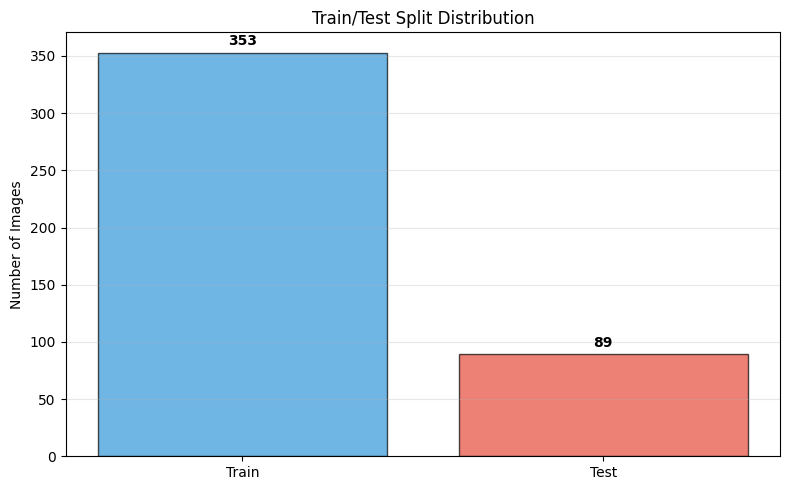

In [8]:
# create a simple bar chart
plt.figure(figsize=(8, 5))
splits = ['Train', 'Test']
counts = [len(train_files), len(test_files)]
colors = ['#3498db', '#e74c3c']

plt.bar(splits, counts, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Number of Images')
plt.title('Train/Test Split Distribution')
plt.grid(axis='y', alpha=0.3)

# add count labels on bars
for i, (split, count) in enumerate(zip(splits, counts)):
    plt.text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directories:")
print(f"\tTrain: {train_dir}")
print(f"\tTest: {test_dir}")

Created directories:
	Train: /home/saber/workspaces/irwin_ws/fyp/datasets/torpedo_boat_imagery/251028_random-split/251028_random-split_train-data
	Test: /home/saber/workspaces/irwin_ws/fyp/datasets/torpedo_boat_imagery/251028_random-split/251028_random-split_test-data


In [10]:
# function to copy or move files with progress
def transfer_files(file_list, dest_dir, action='copy'):
    transfer_func = shutil.copy if action == 'copy' else shutil.move
    
    for i, filename in enumerate(file_list, 1):
        src_path = os.path.join(source_dir, filename)
        dst_path = os.path.join(dest_dir, filename)
        transfer_func(src_path, dst_path)
        
        # Progress update every 100 files
        if i % 100 == 0 or i == len(file_list):
            print(f"\tProcessed {i}/{len(file_list)} files...")

action = 'copy' if copy_files else 'move'
print(f"Starting to {action} files...")

print(f"Processing training set:")
transfer_files(train_files, train_dir, action)

print(f"Processing test set:")
transfer_files(test_files, test_dir, action)

print(f"Done! Files have been {action}ed successfully.")

Starting to copy files...
Processing training set:
	Processed 100/353 files...
	Processed 200/353 files...
	Processed 300/353 files...
	Processed 353/353 files...
Processing test set:
	Processed 89/89 files...
Done! Files have been copyed successfully.


In [11]:
# count files in each directory
train_count = len([f for f in os.listdir(train_dir) if any(f.endswith(ext) for ext in image_extensions)])
test_count = len([f for f in os.listdir(test_dir) if any(f.endswith(ext) for ext in image_extensions)])

print(f"Verification:")
print(f"\tExpected train: {len(train_files)} | Actual: {train_count}\n")
print(f"\tExpected test: {len(test_files)} | Actual: {test_count}\n")

if train_count == len(train_files) and test_count == len(test_files):
    print(f"All files transferred successfully!")
else:
    print(f"Warning: File counts don't match. Please check.")

Verification:
	Expected train: 353 | Actual: 353

	Expected test: 89 | Actual: 89

All files transferred successfully!
